# Computer Vision

## Problem Statement - Part - A

To build a face recognition system

## Data Dictionary 

The dataset contains the following data 

- label: Identifies the object in the image
- notes: Additional comments (currently empty)
- points: Coordinates of the mask (top-left and bottom-right)
- imageWidth: Width of the image in pixels
- imageHeight: Height of the image in pixels

### Let us import some essential libraries

In [12]:
import cv2
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
import zipfile
import os
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, Dropout, Flatten, Activation, MaxPooling2D, UpSampling2D, Concatenate,Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet import preprocess_input
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow import reduce_sum
from tensorflow.keras.backend import epsilon
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.backend import log
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from ultralytics import YOLO

### Reading the dataset

In [263]:
data = np.load('Images.npy',allow_pickle=True)

### Data Processing & Transformations

In [266]:
num_samples = data.shape[0]
image_size = 224
images = np.zeros((num_samples, image_size, image_size, 3), dtype=np.float32)
masks = np.zeros((num_samples, image_size, image_size), dtype=np.float32)

for item in range(num_samples):
    original_img = data[item][0]
    resized_img = cv2.resize(original_img, (image_size, image_size), interpolation=cv2.INTER_CUBIC)
    try:
      resized_img = resized_img[:, :, :3]
    except:
      continue

    images[item] = preprocess_input(np.array(resized_img,dtype = np.float32))

    for annotation in data[item][1]:
        x_start = int(annotation["points"][0]['x'] * image_size)
        x_end = int(annotation["points"][1]['x'] * image_size)
        y_start = int(annotation["points"][0]['y'] * image_size)
        y_end = int(annotation["points"][1]['y'] * image_size)

        masks[item, y_start:y_end, x_start:x_end] = 1

- Segregating the images and and assigning the actual masks

### Visualization of the images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


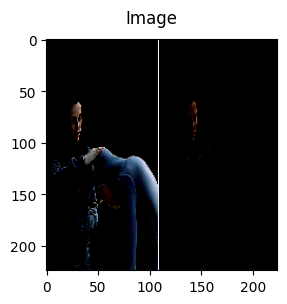

In [267]:
plt.figure(figsize=(8,3))
plt.suptitle(f'Image')
plt.imshow(images[0])

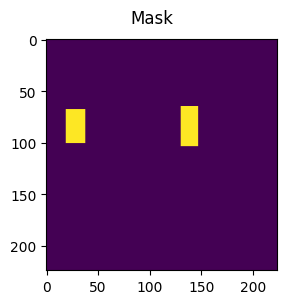

In [268]:
plt.figure(figsize=(8,3))
plt.suptitle(f'Mask')
plt.imshow(masks[0])

### Splitting the data into train and test

In [269]:
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)
print(len(X_train), len(y_train), len(X_test), len(y_test))

314 314 79 79


### Designing a face mask detection model of Mobile Net

In [272]:
def create_model(trainable=True):
    model = MobileNet(input_shape=(224, 224, 3), include_top=False, alpha=1.0, weights="imagenet")

    for layer in model.layers:
        layer.trainable = trainable

    block0 = model.get_layer("conv_pw_1_relu").output
    block1 = model.get_layer("conv_pw_3_relu").output
    block2 = model.get_layer("conv_pw_5_relu").output
    block3 = model.get_layer("conv_pw_11_relu").output
    block4 = model.get_layer("conv_pw_13_relu").output

    x = Concatenate()([UpSampling2D()(block4), block3])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block2])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block1])
    print(x.shape)
    x = Concatenate()([UpSampling2D()(x), block0])
    print(x.shape)
    x = UpSampling2D()(x)
    print(x.shape)
    x = Convolution2D(1, kernel_size=1, activation="sigmoid")(x)
    x = Reshape((224, 224))(x)
    print(x.shape)

    return Model(inputs=model.input, outputs=x)

In [273]:
model = create_model()
model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(None, 14, 14, 1536)
(None, 28, 28, 1792)
(None, 56, 56, 1920)
(None, 112, 112, 1984)
(None, 224, 224, 1984)
(None, 224, 224)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_26[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1           │ (None, 112, 112,  │        288 │ conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_bn        │ (None, 112, 112,  │        128 │ conv_dw_1[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_1_relu      │ (None, 112, 112,  │          0 │ conv_dw_1_bn[0][… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1 (Conv2D)  │ (None, 112, 112,  │      2,048 │ conv_dw_1_relu[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_bn        │ (None, 112, 112,  │        256 │ conv_pw_1[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_1_relu      │ (None, 112, 112,  │          0 │ conv_pw_1_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pad_2          │ (None, 113, 113,  │          0 │ conv_pw_1_relu[0… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2           │ (None, 56, 56,    │        576 │ conv_pad_2[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_bn        │ (None, 56, 56,    │        256 │ conv_dw_2[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_dw_2_relu      │ (None, 56, 56,    │          0 │ conv_dw_2_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2 (Conv2D)  │ (None, 56, 56,    │      8,192 │ conv_dw_2_relu[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_bn        │ (None, 56, 56,    │        512 │ conv_pw_2[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_pw_2_relu      │ (None, 56, 56,    │          0 │ conv_pw_2_bn[0][

 Total params: 3,230,849 (12.32 MB)

 Trainable params: 3,208,961 (12.24 MB)

 Non-trainable params: 21,888 (85.50 KB)

- The total trainable params are nearly 3M while non-trainable are 21K

#### Defining a dice coefficient function to evaluate the outputs and reduce the loss

In [275]:
def dice_coefficient(y_true, y_pred):
    numerator = reduce_sum(y_true * y_pred)
    denominator = reduce_sum(y_true + y_pred)
    return numerator / (denominator + epsilon())

- Keeping the epison in the denominator to take care of cases of non-zero denominator

#### Defining the loss function to find the optimal minima of the cost function

In [277]:
def loss(y_true, y_pred):
    return binary_crossentropy(y_true, y_pred) - log(dice_coefficient(y_true, y_pred) + epsilon())

- The denominator has epsilon to be on the safe  side for take care of non-zero denominator

In [278]:
model.compile(loss=loss, optimizer='adam', metrics=[dice_coefficient])

#### Defining callbacks to find the optimal global minima without overfitting or underfitting 

In [281]:
stop = EarlyStopping(monitor="loss", patience=5, mode="min")
reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")

In [282]:
model.fit(X_train, y_train, epochs=10, batch_size=1, callbacks=[reduce_lr, stop])

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 244s 708ms/step - dice_coefficient: 0.2179 - loss: 2.2329 - learning_rate: 0.0010
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 199s 633ms/step - dice_coefficient: 0.2971 - loss: 1.6542 - learning_rate: 0.0010
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 189s 603ms/step - dice_coefficient: 0.3316 - loss: 1.3271 - learning_rate: 0.0010
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 184s 587ms/step - dice_coefficient: 0.3303 - loss: 1.3765 - learning_rate: 0.0010
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 193s 616ms/step - dice_coefficient: 0.3534 - loss: 1.2863 - learning_rate: 0.0010
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 194s 619ms/step - dice_coefficient: 0.3605 - loss: 1.2727 - learning_rate: 0.0010
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 194s 617ms/step - dice_coefficient: 0.3690 - loss: 1.3822 - learning_rate: 0.0010
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 191s 608ms/step - dice_coefficient: 0.3879 - loss: 1.0879 - learning_rate: 0.0010
Epoch 9/10
314/314 ━━━━━

### Testing on the images of the test dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


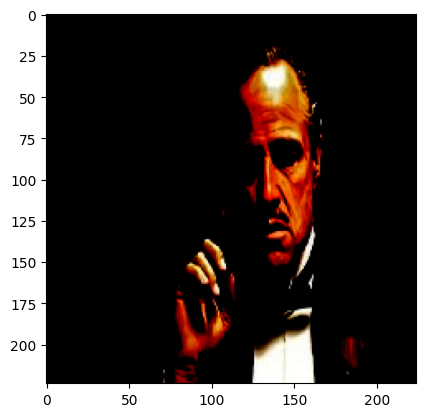

In [283]:
plt.imshow(X_test[10])

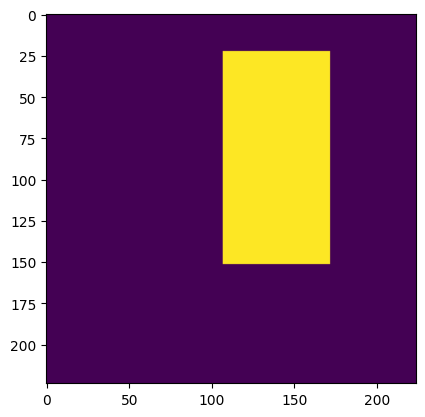

In [285]:
plt.imshow(y_test[10])

In [290]:
pred_mask = cv2.resize(1.0 * (model.predict(x=np.array([X_test[10]]))[0] > 0.5), (224, 224))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


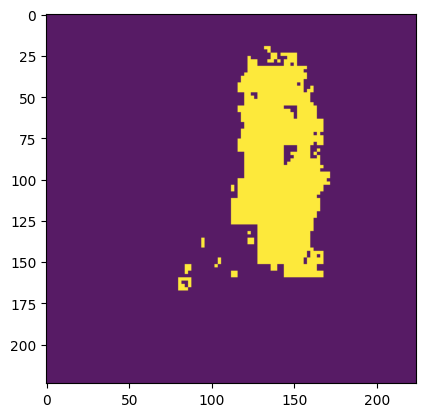

In [291]:
plt.imshow(pred_mask, alpha=0.9)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


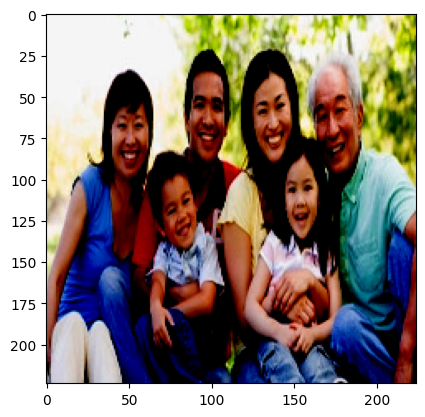

In [294]:
plt.imshow(X_test[77])

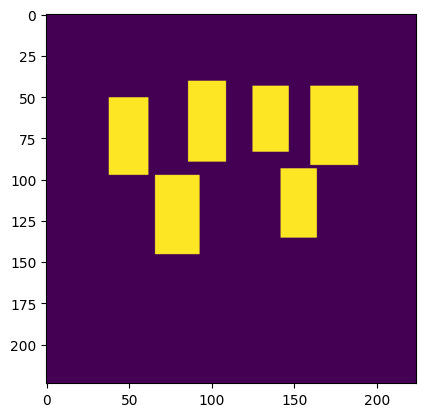

In [295]:
plt.imshow(y_test[77])

In [296]:
pred_mask = cv2.resize(1.0 * (model.predict(x=np.array([X_test[10]]))[0] > 0.5), (224, 224))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step


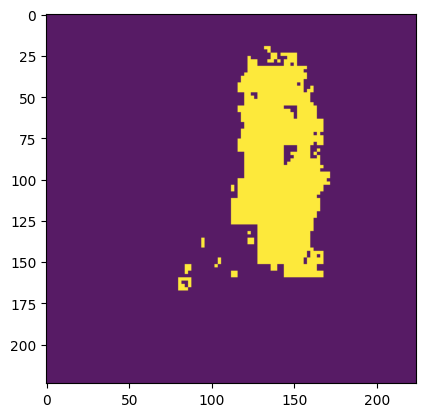

In [297]:
plt.imshow(pred_mask, alpha=0.9)

## Face Detection on images

In [13]:
# Load YOLO face detector
model = YOLO("yolo11n-seg.pt")  # Replace with your face model path

# List all images in the folder
folder_path = "training_images"
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

results_data = []

for file_name in image_files:
    image_path = os.path.join(folder_path, file_name)
    # Run detection
    results = model(image_path)
    # Loop through detections in the image
    for box in results[0].boxes:
        # Get x1, y1, x2, y2
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        # Save metadata row
        results_data.append({
            "Image": file_name,
            "Face_X": int(x1),
            "Face_Y": int(y1),
            "Face_Width": int(x2 - x1),
            "Face_Height": int(y2 - y1),
            "Confidence": conf
        })

# Create DataFrame and save to CSV
df = pd.DataFrame(results_data)
df.to_csv("faces_data.csv", index=False)
print("Data saved to 'faces_data.csv'")


100%|██████████| 5.90M/5.90M [00:00<00:00, 7.90MB/s]



image 1/1 c:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\training_images\real_00001.jpg: 640x640 1 person, 329.4ms
Speed: 20.6ms preprocess, 329.4ms inference, 18.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\training_images\real_00002.jpg: 640x640 1 person, 165.5ms
Speed: 8.2ms preprocess, 165.5ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\training_images\real_00003.jpg: 640x640 1 person, 187.7ms
Speed: 7.3ms preprocess, 187.7ms inference, 5.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 c:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\training_images\real_00004.jpg: 640x640 1 person, 178.2ms
Speed: 8.8ms preprocess, 178.2ms inference, 4.9ms postprocess per image 

- Used YOLOv11 model to detect faces and accordingly find the confidence score with respect to each images and the bounding box coordinates for the same.

## Problem Statement - Part - B

To create an image dataset to be used by the AI team to build  image classifier data

## Data Dictionary 

The dataset comprises facial images that may contain either multiple individuals or single individual per image.

### Reading the Dataset

In [8]:
zip_path = 'PINS.zip'

In [9]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

### Meta Data creation of the images extracted

In [19]:
class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    

def load_metadata(path):
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

metadata = []
load_metadata(r"C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS")


array([C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_Aaron Paul\Aaron Paul0_262.jpg,
       C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_Aaron Paul\Aaron Paul101_247.jpg,
       C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_Aaron Paul\Aaron Paul101_248.jpg,
       ...,
       C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_zendaya\zendaya97.jpg,
       C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_zendaya\zendaya98.jpg,
       C:\Users\lenovo\Documents\Aryan - Great Lakes Learning\graded_evaluation\Computer Vision\PINS\pins_zendaya\zendaya99.jpg],
      dtype=object)

### Converting BGR to RGB format for images

In [27]:
def load_image (image_path):
    image = cv2.imread(image_path)
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return rgb_image

In [28]:
load_image(metadata[0].image_path())

array([[[233, 188, 165],
        [231, 186, 163],
        [220, 178, 156],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       [[232, 187, 164],
        [233, 188, 165],
        [220, 178, 156],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       [[230, 186, 161],
        [228, 184, 159],
        [206, 164, 140],
        ...,
        [106,  63,  72],
        [106,  63,  72],
        [106,  63,  72]],

       ...,

       [[198, 118,  91],
        [197, 120,  94],
        [195, 119,  95],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]],

       [[200, 120,  93],
        [200, 120,  93],
        [198, 121,  95],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]],

       [[201, 121,  94],
        [201, 121,  94],
        [199, 122,  96],
        ...,
        [ 78,  66,  76],
        [ 78,  66,  76],
        [ 78,  66,  76]]

### Defining the VGG model

In [31]:
def vgg_face():
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model


model = vgg_face()
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Generating Embeddings

In [ ]:
img_path = metadata[0].image_path()
img = load_image(img_path)

img = (img / 255.).astype(np.float32)
img = cv2.resize(img, dsize = (224,224))
print(img.shape)
embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 833ms/step
(2622,)


- Based on converting one image from the dataset, if there is any error in converting any image to embeddings, would declare it as converting to a embedding of zeros of size 2622

In [37]:
embeddings = np.zeros((len(metadata), 2622))

for i, m in enumerate(metadata):
    image_path = metadata[i].image_path()
    img = load_image(image_path)
    img = (img/255).astype(np.float32)
    img = cv2.resize(img,dsize=(224,224))
    try:
        embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img,axis=0))[0]
        embeddings[i]=embedding_vector
    except Exception as e:
        embedding_vector = np.zeros(2622)
        embeddings[i] = embedding_vector 

embeddings.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

(10770, 2622)

### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Eucliean Distance"
- Euclidean distance between 2 points (x1, y1) and (x2, y2) = ((x1-x2)^2 + (y1-y2)^2) ^ 0.5

In [45]:
def distance(emb1, emb2):
    return np.sqrt(np.sum(np.square(emb1 - emb2)))

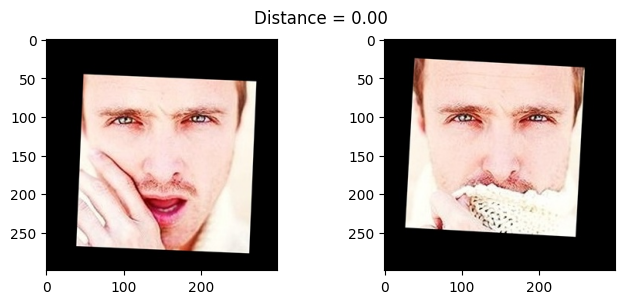

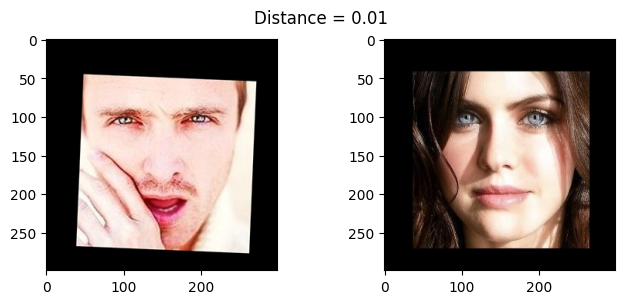

In [46]:
def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

show_pair(2, 3)
show_pair(2, 180)

### Insights

- The first figure has pretty similar faces, hence the distance is smaller
- The second figure talks about two different and divergent faces, hence the distance is slightly bigger

### Splitting into train and test data

In [50]:
train_idx = np.arange(len(metadata)) % 9 != 0
test_idx = np.arange(len(metadata)) % 9 == 0

X_train = embeddings[train_idx]
X_test = embeddings[test_idx]

targets = np.array([m.name for m in metadata])
y_train = targets[train_idx]
y_test = targets[test_idx]

### Encoding the targets using label-encoder

In [136]:
label_encoder = LabelEncoder()

encoded_y_train = label_encoder.fit_transform(y_train)
encoded_y_test = label_encoder.transform(y_test)

encoded_y_train

array([ 0,  0,  0, ..., 99, 99, 99])

- There are 100 unique values for 100 people in the dataset

### Scaling the features using Standard scaler

In [137]:
standard_scaler = StandardScaler()

scaled_X_train = standard_scaler.fit_transform(X_train)
scaled_X_test = standard_scaler.transform(X_test)

scaled_X_train

array([[ 1.56142623,  0.45419832,  1.46618667, ..., -1.57445278,
         1.15125709,  1.55070013],
       [ 1.18376071, -0.22411307,  2.01972716, ..., -2.14156164,
         0.73959469,  1.18287177],
       [ 0.46432674, -0.16705804,  1.28304714, ..., -1.10705382,
        -0.74044224,  0.62068985],
       ...,
       [-1.81793453,  0.30784722, -0.91233903, ...,  0.02065839,
        -1.53258381, -0.79111264],
       [-1.98549938, -1.13161672,  0.11769154, ...,  0.06738223,
        -0.61966409, -1.96810409],
       [-1.71788363, -0.40931027, -1.56755324, ...,  1.63895725,
         0.07512363, -0.70214831]])

- Scaling the data to reduce the chances of overfitting of data

### Performing dimensionality reduction to decrease the compute required using PCA

In [138]:
pca  = PCA(n_components=128)

dim_reduced_scaled_X_train = pca.fit_transform(scaled_X_train)
dim_reduced_scaled_X_test = pca.transform(scaled_X_test)

dim_reduced_scaled_X_train

array([[-5.90819443e+01,  5.69665405e+00, -1.38103870e+01, ...,
         2.14386821e-02,  5.50351396e-01,  3.73047046e-01],
       [-5.18077037e+01,  2.25511792e+00, -2.28752403e+01, ...,
        -1.20884018e-01,  2.07153412e+00, -1.49837820e+00],
       [-5.67952959e+01, -1.23846675e+01, -2.19391078e+01, ...,
        -2.48288355e+00,  5.97242692e-01,  2.10880755e-01],
       ...,
       [ 1.95645619e+01, -6.76795054e+00, -2.22535554e+01, ...,
        -6.67391667e-01, -1.48100693e-01,  7.25222995e-02],
       [ 2.16826009e+01, -1.22611439e+01, -1.40522300e+01, ...,
         1.76197961e+00, -6.94952363e-01, -1.38353722e+00],
       [ 2.90515011e+01,  5.13962380e+00,  4.15583578e+00, ...,
         6.67784057e-01, -4.69953329e-01, -5.51649845e-01]])

- Reduced the dimension of the embeddings to 128 for effective and efficient computations

### Training the SVM Classifier to classify images

In [139]:
SVM = SVC(gamma=0.025,C=4,kernel='rbf')
SVM.fit(dim_reduced_scaled_X_train,encoded_y_train)

,C,4
,kernel,'rbf'
,degree,3
,gamma,0.025
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [140]:
y_pred = SVM.predict(dim_reduced_scaled_X_test)
accuracy = accuracy_score(encoded_y_test,y_pred)
print ("Accuracy:",accuracy)

Accuracy: 0.028404344193817876


### Importing and displaying images

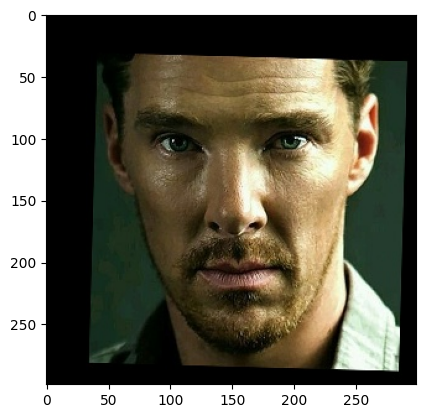

In [141]:
img1_path = "Benedict Cumberbatch9.jpg"
plt.imshow(load_image(img1_path))

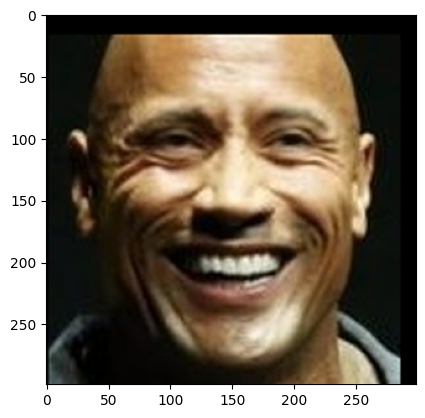

In [142]:
img2_path = "Dwayne Johnson4.jpg"
plt.imshow(load_image(img2_path))

### Testing on unseen images

In [143]:
def predict_person_in_image(img_path):
    img = load_image(img_path)

    img = (img / 255.).astype(np.float32)
    img = cv2.resize(img, dsize = (224,224))
    print(img.shape)

    embedding_vector_img = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))
    print(embedding_vector_img)
    scaled_embedding_vector = standard_scaler.transform(embedding_vector_img)
    dim_reduced_embedding_vector_img = pca.transform(scaled_embedding_vector)

    img_person = SVM.predict(dim_reduced_embedding_vector_img)
    person = label_encoder.inverse_transform(img_person)
    print (person)
    return person

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
[[ 3.1725955e-04 -7.5013086e-05  3.4382584e-04 ... -2.4794071e-04
   2.9112317e-04  1.4736241e-04]]
['pins_Benedict Cumberbatch']


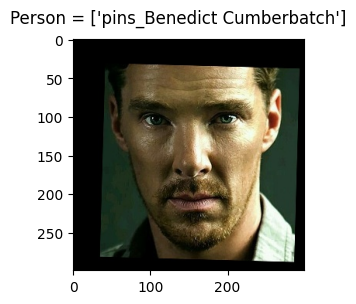

In [144]:
person = predict_person_in_image(img1_path)
plt.figure(figsize=(8,3))
plt.suptitle(f'Person = {person}')
plt.imshow(load_image(img1_path))

(224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
[[ 3.7590609e-04  2.9195216e-05  1.2519164e-04 ... -2.1153508e-04
   7.1857736e-05  1.4152309e-04]]
['pins_Dwayne Johnson']


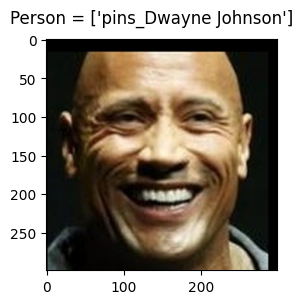

In [145]:
person = predict_person_in_image(img2_path)
plt.figure(figsize=(8,3))
plt.suptitle(f'Person = {person}')
plt.imshow(load_image(img2_path))

### Actionable Insights and Recommendations

- The mobileNet architecture is great for detecting single faces in an image, but when we have to detect multiple faces, using better models like InceptionNet, UNet or VGGNet should be preferred.
- For constructing embeddings, using VGGNet might not be the excellent choice, since the accuracy is very low. 
- Using Yolov11 for face detection is most useful since it is one-stage detector mechanism as compared to other models which are two stage detector mechanism.
- Using SVM as a classifier algorithm might not be very useful, instead using clustering techniques to classify the images based on the cluster in which the model predicts that image should be might be a better bet.